## 케글 수어 데이터셋
- 미국 수어(ASL, American Sign Language)의 알파벳 손짓을 $28 \times 28$ 흑백 이미지 형태의 수치 데이터로 변환한 데이터셋입니다.
- 포함 라벨: A, B, C, D, E, F, G, H, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y
    - 제외된 라벨 (J, Z):
    - 알파벳 J와 Z는 정적인 손 모양이 아니라 손가락을 움직이는 동작(Motion)이 포함되어야 표현되는 수어입니다.
    - 단일 정지 이미지로는 표현할 수 없어 데이터셋에서 완전히 제외되었습니다. (라벨 9번과 25번이 비어 있음)

[케글 수어 데이터셋](https://www.kaggle.com/datasets/datamunge/sign-language-mnist)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

import torch
import torch.nn as nn
import torch.optim as optim

import sklearn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 데이터를 가져오는 모듈
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, Dataset, DataLoader

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# sklearn.set_config(display="text")

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: mps


In [3]:
# 수어 데이터셋 CSV 파일을 아래 경로에서 불러옵니다.

In [4]:
base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
train_file_path = os.path.join(base_path, "sign_mnist_train.csv")
test_file_path = os.path.join(base_path, "sign_mnist_test.csv")

In [5]:
train_df  = pd.read_csv(train_file_path)
test_df  = pd.read_csv(test_file_path)

In [6]:
test_df.head(1)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107


In [7]:
np.sqrt(784)

np.float64(28.0)

In [8]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values
X_test= test_df.iloc[:, 1:].values
y_test= test_df.iloc[:, 0].values

In [9]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(27455, 784) (27455,)
(7172, 784) (7172,)


In [10]:
len(pd.Series(y_train).unique())

24

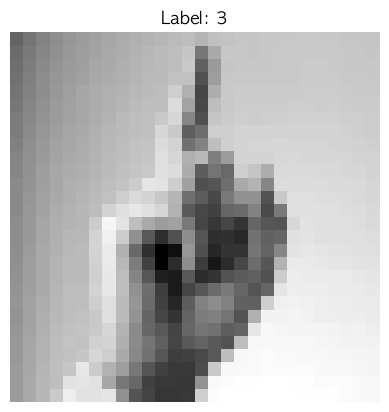

In [11]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [12]:
import string

alphabets = [char for char in string.ascii_uppercase if char not in ["J", "Z"]]
# classes_dict = dict(enumerate(alphabets))
# enumerate : 반복 가능안 데이터에 인덱스 를 붙여주는 함수 
classes_dict =  {}
idx = 0 
for char in string.ascii_uppercase:
    if char in ["J", "Z"]:
        continue
    classes_dict[idx] = char
    idx += 1 if char != "I" else 2

print(classes_dict)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}


## 데이터 증강 실습 

In [13]:
# 1. 데이터 전처리 

In [14]:
# 4. 데이터 다운로드 및 불러오기

In [15]:
# 5. 데이터를 배치 단위로 나누기

In [16]:
# 6. 모델 만들기

In [17]:
# 7. 손실 함수와 최적화 도구

In [18]:
# 8. 모델 학습

In [21]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) / 225.0
X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 225.0
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

## TensorData 준비


In [22]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## 데이터 종강 

In [23]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0), # 무조건 좌우반전 
    transforms.RandomVerticalFlip(p=0.5),   # 50% 확률로 상하반전
    transforms.RandomRotation(degrees=(90, 90))
])

In [33]:
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        if self.transform:
            x = x.view(28, 28).unsqueeze(0)
            x = self.transform(x)
            x = x.flatten()
        return x, y

In [34]:
train_aug_dataset = AugmentedDataset(train_dataset, train_transform)

## 데이터 로더 

In [35]:
train_loader = DataLoader(train_aug_dataset, batch_size=64, shuffle=True)

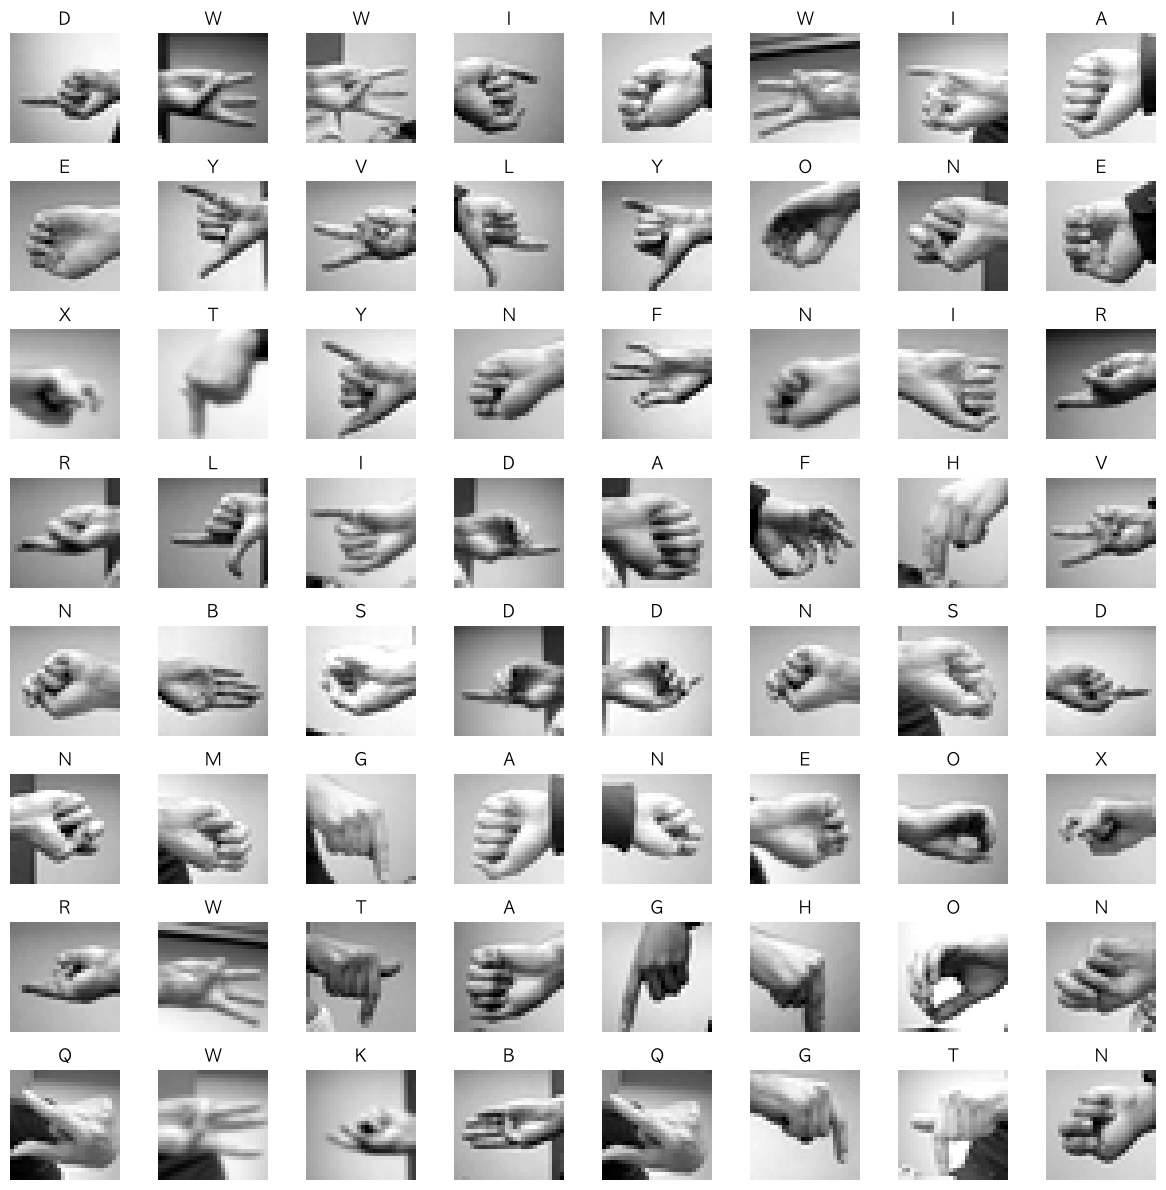

In [37]:
ims, labels = next(iter(train_loader))

plt.figure(figsize=(12, 12))
for i in range(min(64, len(ims))):
    plt.subplot(8, 8, i + 1)
    plt.imshow(ims[i].view(28, 28), cmap="gray")
    plt.title(classes_dict[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

ahepf wnsql## 

In [40]:
model = nn.Sequential(
    nn.Linear(28 * 28, 25)
    
)

In [41]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device="cpu"

In [ ]:

def evaluate(model, 0
    model.ev()
    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        # 평가
        y_pred = model(X_batch)  # 순전파
        loss = criterion(y_pred, y_batch) # 손실 

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)
    print(f"{epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}")


In [ ]:
epochs = 50 

for epoch in range(epochs):
    avg_loss, avg_acc = train_onr_epoch(model, trin_loader, criterion, optimizer)
    print(f"Epoch: {epoch + 1}/{epochs}| loss: {avg_loss:.4f} | Accruacy: {avg_acc:,2f}%")

In [ ]:
# 쓰레기모델 = 과소 적합 

In [ ]:
e

## 잘못된 데이터의 종강은 오히려 과소 적합을 발생시칼 수 있다  

In [ ]:
train_transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=1.0), # 무조건 좌우반전 
    # transforms.RandomVerticalFlip(p=0.5),   # 50% 확률로 상하반전
    transforms.RandomRotation(degrees=(10, 10))
])